# Trabajo Práctico: Probabilidad y Decisiones
## Dataset: Bank Marketing (bank.csv)

**Estudiante:** Dylan Gross   
**Curso:** Data Science   
Semana 4, Clase 4

**Fuente de los datos:**
Moro, S., Rita, P. y Cortez, P. (2014). *Bank Marketing*. UCI Machine Learning Repository.
https://doi.org/10.24432/C5K306 — Licencia CC BY 4.0

**Pregunta central:**
¿Qué proporción de los registros terminó en suscripción y cuánto cambia esa estimación al trabajar con distintas muestras?

In [23]:
import pandas as pd

datos = pd.read_csv("bank.csv", sep=";")

print("Shape:", datos.shape)
print()
display(datos.head())
print()
datos.info()

Shape: (4521, 17)



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


| Elemento | Definición para este trabajo |
|---|---|
| Unidad de análisis | Un registro de cliente dentro de la campaña |
| Población registrada | Los registros incluidos en bank.csv |
| Evento de interés (S) | El registro tiene y = "yes" |
| Denominador | Registros con un valor válido en y |

In [14]:
# Cantidad de filas duplicadas
duplicados = datos.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

# Valores faltantes por columna
faltantes = datos.isnull().sum()
print("\nValores faltantes por columna:")
print(faltantes)

Filas duplicadas: 0

Valores faltantes por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


**Revisión inicial:**
- Filas duplicadas: 0
- Valores faltantes: 0 en todas las columnas
→ El dataset está limpio, no requiere tratamiento previo.

In [15]:
# Frecuencia absoluta
frec_y = datos["y"].value_counts()
print("Frecuencia absoluta:")
print(frec_y)

# Porcentajes
porc_y = datos["y"].value_counts(normalize=True) * 100
print("\nPorcentajes (%):")
print(porc_y.round(2))

Frecuencia absoluta:
y
no     4000
yes     521
Name: count, dtype: int64

Porcentajes (%):
y
no     88.48
yes    11.52
Name: proportion, dtype: float64


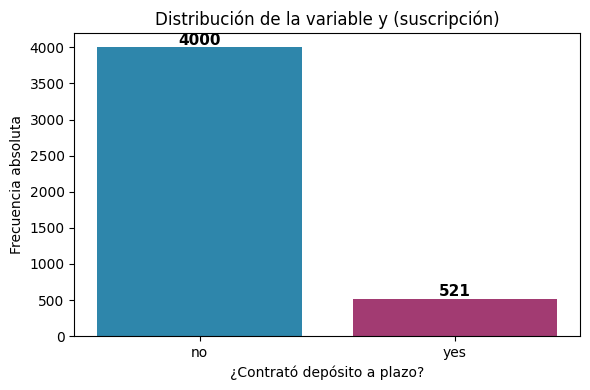

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(frec_y.index, frec_y.values, color=["#2E86AB", "#A23B72"])

ax.set_title("Distribución de la variable y (suscripción)")
ax.set_xlabel("¿Contrató depósito a plazo?")
ax.set_ylabel("Frecuencia absoluta")

# Valores visibles arriba de cada barra
for b, v in zip(barras, frec_y.values):
    ax.text(b.get_x() + b.get_width()/2, v + 30, str(v),
            ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [17]:
# Resumen de cuartiles
resumen = datos["campaign"].describe()
print("Resumen de campaign:")
print(resumen[["min", "25%", "50%", "75%", "max"]])

Resumen de campaign:
min     1.0
25%     1.0
50%     2.0
75%     3.0
max    50.0
Name: campaign, dtype: float64


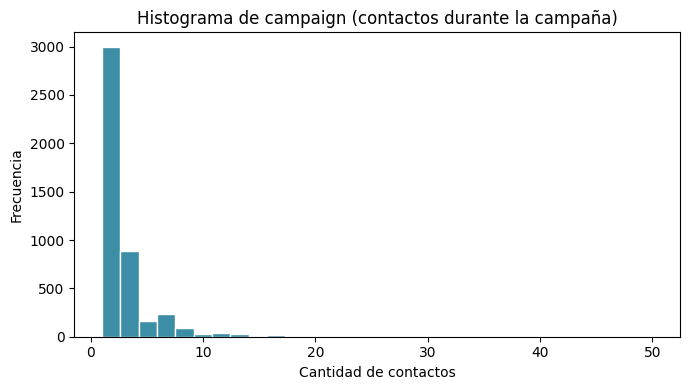

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(datos["campaign"], bins=30, color="#3B8EA5", edgecolor="white")
ax.set_title("Histograma de campaign (contactos durante la campaña)")
ax.set_xlabel("Cantidad de contactos")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

**Forma de la distribución de `campaign`:**
La distribución es fuertemente asimétrica hacia la derecha: la mayoría de los clientes fue contactado pocas veces (mediana = 2, tercer cuartil = 3), mientras que los valores más altos (cola larga, hasta 50) corresponden a unos pocos clientes con muchos contactos.

In [19]:
# Totales
n_total = datos.shape[0]
n_yes = (datos["y"] == "yes").sum()
n_no  = (datos["y"] == "no").sum()

# Proporciones
p_s  = n_yes / n_total      # P(S)
p_no = n_no  / n_total      # P(no S)

print(f"P(S)    = {n_yes} / {n_total} = {p_s:.4f} = {p_s*100:.2f} %")
print(f"P(no S) = {n_no}  / {n_total} = {p_no:.4f} = {p_no*100:.2f} %")
print(f"\nSuma de proporciones: {p_s + p_no:.4f}  (debe dar 1)")

P(S)    = 521 / 4521 = 0.1152 = 11.52 %
P(no S) = 4000  / 4521 = 0.8848 = 88.48 %

Suma de proporciones: 1.0000  (debe dar 1)


**Proporción observada:**

- **P(S) = 521 / 4521 = 0.1152 = 11.52 %** → proporción de registros que terminaron en suscripción.
- **P(no S) = 4000 / 4521 = 0.8848 = 88.48 %** → proporción complementaria.

**Verificación:** P(S) + P(no S) = 0.1152 + 0.8848 = 1.0000 ✓

Es decir: aproximadamente **1 de cada 9 clientes** contactados en esta campaña contrató el depósito a plazo. Esta proporción (11.52 %) será nuestra **referencia observada** en `bank.csv` para comparar con las muestras más pequeñas del Punto 4.

In [20]:
semillas = [1, 2, 3, 4, 5]
resultados = []

for s in semillas:
    muestra = datos.sample(n=300, replace=False, random_state=s)
    suscripciones = (muestra["y"] == "yes").sum()
    proporcion = suscripciones / 300
    resultados.append({
        "Semilla": s,
        "Suscripciones": suscripciones,
        "Tamaño de muestra": 300,
        "Proporción": round(proporcion, 4)
    })

tabla_muestras = pd.DataFrame(resultados)
tabla_muestras

,Semilla,Suscripciones,Tamaño de muestra,Proporción
0,1,41,300,0.1367
1,2,28,300,0.0933
2,3,26,300,0.0867
3,4,31,300,0.1033
4,5,31,300,0.1033


In [21]:
p_min = tabla_muestras["Proporción"].min()
p_max = tabla_muestras["Proporción"].max()
diferencia = p_max - p_min

# Muestra más cercana a la proporción observada en todo bank.csv
tabla_muestras["Distancia_a_P(S)"] = (tabla_muestras["Proporción"] - p_s).abs()
fila_cercana = tabla_muestras.loc[tabla_muestras["Distancia_a_P(S)"].idxmin()]

print(f"P(S) de referencia (bank.csv completo): {p_s:.4f} ({p_s*100:.2f} %)\n")
print(f"1. Proporción mínima: {p_min:.4f} ({p_min*100:.2f} %)")
print(f"   Proporción máxima: {p_max:.4f} ({p_max*100:.2f} %)")
print(f"\n2. Diferencia entre ambas: {diferencia:.4f} ({diferencia*100:.2f} puntos porcentuales)")
print(f"\n3. Muestra más cercana a P(S): semilla {int(fila_cercana['Semilla'])} "
      f"con proporción {fila_cercana['Proporción']:.4f}")

P(S) de referencia (bank.csv completo): 0.1152 (11.52 %)

1. Proporción mínima: 0.0867 (8.67 %)
   Proporción máxima: 0.1367 (13.67 %)

2. Diferencia entre ambas: 0.0500 (5.00 puntos porcentuales)

3. Muestra más cercana a P(S): semilla 4 con proporción 0.1033


**Respuestas:**

1. **Proporción mínima y máxima:** la mínima fue de 8,67 % (semilla 3) y la máxima de 13,67 % (semilla 1).

2. **Diferencia entre ambas:** 5 puntos porcentuales.

3. **Muestra más cercana a P(S) = 11.52 %:** la semilla 4, con proporción 10,33%.

4. **¿Por qué las cinco estimaciones pueden ser distintas aunque provengan del mismo archivo?**
   Porque cada muestra es un **subconjunto aleatorio distinto** de 300 registros extraído sin reemplazo. Al cambiar el subconjunto cambia la cantidad de clientes que dijeron "yes", y por lo tanto la proporción estimada fluctúa alrededor del valor verdadero. Este fenómeno se llama **variabilidad muestral**: aunque todas las muestras vienen de la misma población (los 4.521 registros), el azar del muestreo hace que cada estimación sea un poco distinta. Cuanto más chico es el tamaño de muestra, mayor es esa variabilidad.

In [22]:
costo = 1
beneficio = 12

ve_por_contacto = beneficio * p_s - costo
ve_piloto_100   = ve_por_contacto * 100

print(f"P(S) = {p_s:.4f}")
print(f"Valor esperado neto por contacto: {ve_por_contacto:.4f} unidades")
print(f"Valor esperado neto para 100 contactos: {ve_piloto_100:.2f} unidades")

P(S) = 0.1152
Valor esperado neto por contacto: 0.3829 unidades
Valor esperado neto para 100 contactos: 38.29 unidades


**Análisis del valor esperado:**

1. **Valor esperado neto por contacto:**
   VE = 12 × 0.1152 − 1 = 1.3829 − 1 = **0.3829 unidades** por contacto.
   En promedio, cada contacto deja una ganancia neta de ≈ 0.38 unidades.

2. **Valor esperado neto para un piloto de 100 contactos:**
   VE(100) = 0.3829 × 100 = **38.29 unidades**.
   Es decir, el piloto tendría una ganancia neta esperada de aproximadamente 38 unidades.

3. **¿Realizaría la prueba piloto?**
   **Sí.** El valor esperado es positivo (≈ +0.38 por contacto y ≈ +38.29 para 100 contactos), lo que indica que, en promedio, la campaña resulta rentable bajo los supuestos del escenario. El **supuesto principal** que sostiene esta decisión es que la proporción observada en `bank.csv` (P(S) ≈ 11.52 %) se mantiene como referencia válida para la campaña futura, y que el costo (1) y el beneficio (12) por unidad se mantienen constantes.

## 6. Cierre

1. **Proporción de suscripción observada:** se observa que **521 de 4521** registros terminaron en suscripción, es decir **P(S) ≈ 0.1152 (11.52 %)**; la proporción complementaria es **0.8848 (88.48 %)**. Ambas suman 1.

2. **Variación entre las cinco muestras:** la muestra indica proporciones que van desde **8.67 % hasta 13.67 %**, una diferencia de **5.00 puntos porcentuales**. Esta dispersión refleja la **variabilidad muestral** esperable al tomar submuestras de 300 registros sin reemplazo del mismo archivo.

3. **Decisión propuesta y supuesto principal:** se propone **avanzar con el piloto de 100 contactos**, ya que el valor esperado neto es positivo (≈ **+38.29 unidades**). El supuesto principal que sostiene la decisión es que **la proporción de suscripción observada en `bank.csv` (11.52 %) se mantiene como referencia válida** para la campaña futura, junto con los costos (1) y beneficios (12) por unidad constantes.

> Las conclusiones se refieren únicamente a los registros analizados: *"se observa"* o *"la muestra indica"*, sin extrapolar más allá de lo que los datos permiten.